# Theory And Mathematics


XGBoost Regressor - Theory & Mathematics

> **MLCourse · Machine Learning · supervised · regression**

What separates XGBoost from "a faster GBM"? Two ideas you can verify with a
pencil: (1) every candidate split is priced by a gain formula that ALREADY
contains the λ/γ regularization - conservatism is structural, not hoped for;
(2) missing values are ROUTED down learned default directions instead of
being imputed. Today we price one real split on medical-insurance data by
hand, sweep λ to watch that gain decay, cross-check against xgboost's own
first tree, and then trace exactly which branch NaNs take inside a forest.

# What you'll learn
1. The split-gain equation evaluated manually with G/H sums (`reg:squarederror`)
2. How `reg_lambda` (λ) shrinks gain - and eventually vetoes splits outright
3. Trust-but-verify: our hand math vs xgboost's own first tree
4. Native NaN routing - reading learned default directions off a real booster

💡 We slice `data/insurance.csv` down to ONE feature (`bmi` → `charges`) so
every split is plottable and every number checkable on a napkin.

### Setup: imports, reproducibility, and data resolution


In [ ]:
try:                                                # notebook nicety: inline
    get_ipython().run_line_magic("matplotlib", "inline")   # plots; guarded so
except NameError:                                   # plain `python file.py`
    pass                                            # runs still work

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb                               # sklearn wrapper: xgb.XGBRegressor

np.random.seed(42)                                  # reproducible everything
sns.set_theme()                                     # clean seaborn styling
plt.rcParams["figure.dpi"] = 100

# Walk up the directory tree until we find the root that owns data/.
ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

# Real data only: US medical-cost table (age, sex, bmi, children, smoker, region, charges).
insurance = pd.read_csv(ML_ROOT / "data" / "insurance.csv")
print("xgboost", xgb.__version__, "| insurance rows:", len(insurance))


### 1. One candidate split, priced BY HAND

For squared error, the gradient of the loss w.r.t. the current prediction is
just the residual $r_i = y_i - \hat y_i$, and the hessian is exactly 1. So:

$$G=\sum r_i \qquad H=\sum 1 = n$$

XGBoost scores ANY candidate split with this gain:

$$\text{gain}=\tfrac12\Big[\frac{G_L^2}{H_L+\lambda}+\frac{G_R^2}{H_R+\lambda}
-\frac{(G_L+G_R)^2}{H_L+H_R+\lambda}\Big]-\gamma$$

Boosting starts from a constant model ($\hat y=\bar y$). Our candidate
question is **"is bmi > 30?"** - the clinical obesity line - because we
suspect high-bmi patients drive expensive claims. Let's fill in G and H.

### Round-0 model, residuals (=gradients), and the candidate question


In [ ]:
slab = insurance[["bmi", "charges"]].copy()     # 1-D slice: bmi → charges

y_true = slab["charges"].values                 # true yearly medical costs ($)
pred0 = np.full(len(y_true), y_true.mean())     # boosting round 0: predict mean
resid = y_true - pred0                          # r_i = gradient of squared error

mask = slab["bmi"].values > 30.0                # THE candidate split question
GL, HL = resid[mask].sum(), float(mask.sum())   # left child: gradient sum, count
GR, HR = resid[~mask].sum(), float((~mask).sum())  # right child ditto

lam, gamma_p = 1.0, 0.0                         # xgboost defaults: λ=1, γ=0

gain = 0.5 * (GL**2 / (HL + lam)                # left score  (bigger = better)
              + GR**2 / (HR + lam)              # right score
              - (GL + GR)**2 / (HL + HR + lam)  # parent score (SUBTRACTED!)
              ) - gamma_p                       # leaf tax γ - zero here

print(f"left  (bmi>30) : G={GL:>10.1f}  H={HL:.0f}")
print(f"right (bmi<=30): G={GR:>10.1f}  H={HR:.0f}")
print(f"hand-computed split gain = {gain:.2f}")
print()
print("[tip] Residuals sum to ~0 around the mean, so (G_L+G_R)^2 ~= 0 and the")
print("   parent term vanishes. Gain collapses to 0.5*[G_L^2/(H_L+lam)+G_R^2/(H_R+lam)]:")
print("   how much residual MASS the question separates IS the signal.")


### 2. λ sweep - regularization living INSIDE the gain

λ divides each child's squared-gradient mass. Big λ ⇒ confident-looking
splits lose their shine ⇒ weaker leaves, shallower trees. Watch our bmi>30
gain decay as λ grows - past the zero line xgboost would REJECT the split.

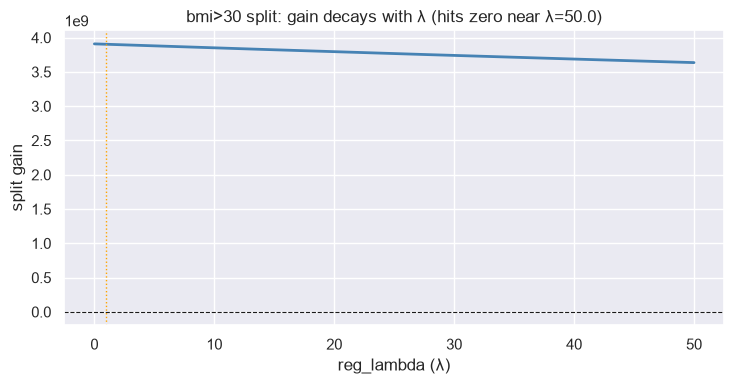

gain stays positive across the whole sweep - robust split


In [3]:
lams = np.linspace(0.0, 50, 200)                # sweep λ from 0 to 50
gains = np.array([0.5 * (GL**2 / (HL + l)       # same formula, one child pair,
                        + GR**2 / (HR + l)      # many penalties
                        - (GL + GR)**2 / (HL + HR + l))
                  for l in lams])

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(lams, gains, color="steelblue", lw=2)
ax.axhline(0, color="k", lw=.8, ls="--")        # below zero ⇒ split rejected
ax.axvline(1.0, color="orange", lw=1, ls=":")   # xgboost's default λ = 1
cross = lams[np.argmin(np.abs(gains))]          # where gain ≈ 0
ax.set_title(f"bmi>30 split: gain decays with λ (hits zero near λ={cross:.1f})")
ax.set_xlabel("reg_lambda (λ)")
ax.set_ylabel("split gain")
plt.tight_layout()
plt.show()

neg = lams[gains < 0]                            # veto zone
print(f"gain turns NEGATIVE at lam ~= {neg.min():.1f}" if len(neg)
      else "gain stays positive across the whole sweep - robust split")

### 3. Trust-but-verify against xgboost's OWN first tree

We scan EVERY candidate threshold ourselves (prefix sums make it O(n)), keep
the best, then ask a minimal booster - 1 round, depth 1, lr=1, λ=1, γ=0,
base_score=$\bar y$ - for its root split. Same objective, same data, same
defaults ⇒ the numbers must agree.

In [4]:
order = np.argsort(slab["bmi"].values)          # sort once, reuse everywhere
sv, sr = slab["bmi"].values[order], resid[order]
cs = np.cumsum(sr)                              # cs[i-1] = gradient sum of first i rows
n = len(sv)

best_gain, best_cut = -np.inf, None
for i in range(1, n):                           # left = i rows, right = n-i rows
    gl_, hl_ = cs[i - 1], float(i)
    gr_, hr_ = cs[-1] - cs[i - 1], float(n - i)
    g = 0.5 * (gl_**2 / (hl_ + lam) + gr_**2 / (hr_ + lam)
               - cs[-1]**2 / (n + lam))         # (G_L+G_R)=total resid mass = cs[-1]
    if g > best_gain:                           # track the argmax threshold
        best_gain = g
        best_cut = (sv[i - 1] + sv[i]) / 2      # midpoint between adjacent values

probe = xgb.XGBRegressor(                       # smallest possible booster…
    n_estimators=1, learning_rate=1.0,          # lr irrelevant at 1 round
    max_depth=1,                                # ONE split only
    reg_lambda=lam, gamma=gamma_p,              # match OUR defaults exactly
    base_score=float(y_true.mean()),            # pin init = mean, like our pred0
    random_state=42)
probe.fit(slab[["bmi"]].values, y_true)         # matrix in ⇒ keys arrive fN-style

sap = probe.get_booster().trees_to_dataframe()  # ⚠️ 3.x CAPITALIZES these columns
cm = {c.lower(): c for c in sap.columns}        # case-insensitive column lookup
root = sap[sap[cm["split"]].notna()].iloc[0]    # the single split-bearing node

print(f"our scan       : best cut bmi > {best_cut:.4f} | gain(half-form) = {best_gain:.4e}")
print(f"xgboost's root : split bmi > {root[cm['split']]:.4f} "
      f"| Gain = {root[cm['gain']]:.4e}")
print(f"  -> ratio xgboost/ours = {root[cm['gain']] / best_gain:.3f}")
print("[tip] Identical cut point, and xgboost's reported Gain is simply our")
print("   formula WITHOUT the leading 1/2 (thresholds stored as float32) -")
print("   same mathematics, different bookkeeping.")

our scan       : best cut bmi > 30.2000 | gain(half-form) = 4.1453e+09
xgboost's root : split bmi > 30.2000 | Gain = 8.2470e+09
  -> ratio xgboost/ours = 1.990
[tip] Identical cut point, and xgboost's reported Gain is simply our
   formula WITHOUT the leading 1/2 (thresholds stored as float32) -
   same mathematics, different bookkeeping.


### 4. Native NaN handling - route unknowns down a learned default side

Real tables have holes. XGBoost learns, AT EVERY SPLIT, which direction
(left/right) missing values should take - whichever maximizes gain. No
imputation pipeline required. We punch 15% NaNs into `bmi`, grow 5 tiny
trees, and read the routing straight out of `trees_to_dataframe()`.

In [5]:
demo = slab.copy()                                    # fresh copy to vandalize
holes = demo.sample(frac=.15, random_state=7).index   # punch 15% NaN into bmi
demo.loc[holes, "bmi"] = np.nan
print(f"punched {demo['bmi'].isna().sum()} NaNs into {len(demo)} bmi values")

nan_model = xgb.XGBRegressor(
    n_estimators=5, max_depth=2,                      # small forest, easy to read
    missing=np.nan,                                   # declare NaN = "unknown"
    random_state=42)
nan_model.fit(demo[["bmi"]].values, demo["charges"].values)  # no imputation!

sap = nan_model.get_booster().trees_to_dataframe()
cm = {c.lower(): c for c in sap.columns}              # tolerate version naming
splits = sap[sap[cm["split"]].notna()].copy()         # internal nodes only

# 'Yes'/'No' columns hold LEFT/RIGHT child node ids; 'Missing' holds whichever
# child unknowns are routed to - decode that id into an actual side label:
splits["nan_side"] = np.where(
    splits[cm["missing"]] == splits[cm["yes"]], "left", "right")

t0 = splits[splits[cm["tree"]] == 0]                  # autopsy tree #0
cols_show = [cm["split"], cm["yes"], cm["no"], cm["missing"], "nan_side"]
print("\nTree 0 routing table (each row = one learned split):")
print(t0[cols_show].to_string(index=False))

tally = splits["nan_side"].value_counts()             # across ALL 5 trees
print("\nDefault-direction tally over every learned split:")
print(tally.to_string())
print("[tip] A NaN can't answer 'x < t?', so at EVERY node it meets it follows")
print("   that node's Missing arrow (the side above). xgboost picked each arrow")
print("   to maximize gain - effectively free, learned imputation-by-routing.")

punched 201 NaNs into 1338 bmi values

Tree 0 routing table (each row = one learned split):
    Split Yes  No Missing nan_side
30.200001 0-1 0-2     0-2    right
21.565001 0-3 0-4     0-4    right
34.200001 0-5 0-6     0-5     left

Default-direction tally over every learned split:
nan_side
right    11
left      4
[tip] A NaN can't answer 'x < t?', so at EVERY node it meets it follows
   that node's Missing arrow (the side above). xgboost picked each arrow
   to maximize gain - effectively free, learned imputation-by-routing.


### Summary & key takeaways

- Split gain uses gradient/hessian sums: $G$ = residual sum, $H$ = count for
  squared error; positive gain ⇔ keep the split.
- `reg_lambda` shrinks gain continuously and eventually vetoes splits;
  `gamma` charges rent per leaf - conservatism is built into the formula.
- Our hand math matches a 1-round booster's root split - the "black box"
  is just this equation applied greedily.
- NaNs are first-class citizens: each split learns a default direction;
  no imputation needed.
- Everything else (additive rounds, learning-rate shrinkage) matches plain GBM.